# Multiple Linear Regression

When we dealing a dataset that have more than one variable x and one variable y. We can't solve this problem using Univariate Linear Regression



## Table of Contents
- [Formula](#Formula)
- [Assumption Test](#Assumption-Test)
  - [Scatter Plot](#Scatter-Plot)
- [Train Model](#Train-Model)
  - [Split Dataset](#Split-Dataset)
  - [Scale Variable](#Scale-Variable)
  - [Optimization](#Optimization)
  - [Evaluation](#Evaluation)
- [Residual Plot](#Residual-Plot)
- [Underfitting](#Underfitting)
  - [Cost Function History](#Cost-Function-History)
  - [Model Complexity](#Model-Complexity)
- [Final Result](#Final-Result)
- [Conclusion](#Conclusion)

In [1]:
url  = "https://raw.githubusercontent.com/sumony2j/Prediction-Using-Multiple-Linear-Regression/refs/heads/main/Advertising.csv"
import pandas as pd
df = pd.read_csv(url)
df.head()

,TV,radio,newspaper,sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


We can see that in this dataset have three variable x (tv, radio, newspaper) and one variable y (sales). In this project we want make a model to predicting sales using tv, radio, newspaper value

## Formula

Based on the dataset that we have, variabley x have three variable (n = 3), so we can write the formula

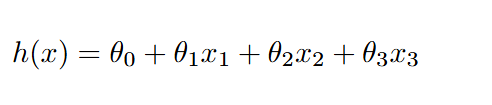

where:

- θ<sub>0</sub> is intercept
- θ<sub>1</sub>,etc is coeficent show how much each attribute contribute to target variable
- x is variable x

So if we want use matrix calculation we can add the intercept wtih x<sub>0</sub> = 0, so we also write the formula (in matrix based)

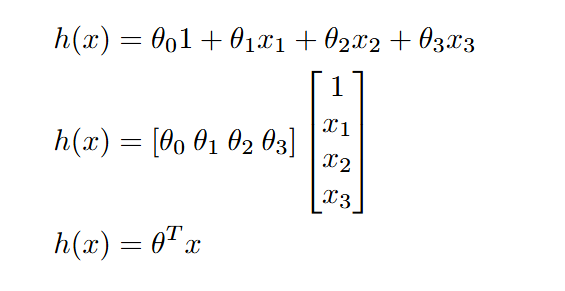

## Asumption Test

We expect that there're linear relatinship between variable x (tv,newspaper, and radio) and target variable (sales). To make sure our asumption is true, we should doing Asumption test first, divide into several part, including :

### Scatter plot

We visualize between variable x and variable y using scatter plot

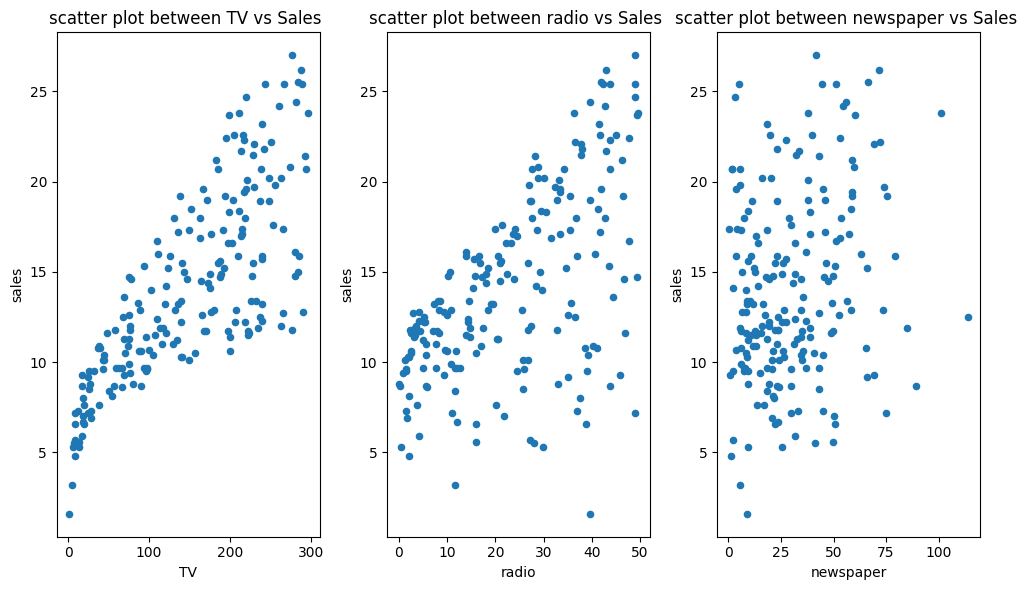

In [2]:
from matplotlib import pyplot as plt
x = ['TV','radio','newspaper']
y = 'sales'
fig,ax = plt.subplots(1,len(x),figsize=(10,6))
ax = ax.ravel()
for i,j in enumerate(x):
    df.plot(kind='scatter',x=j,y=y,ax=ax[i],title=f"scatter plot between {j} vs Sales ")
plt.tight_layout()


Based on the scatter plots, TV advertising appears to have a reasonably strong positive linear relationship with sales, since the data points generally follow an upward trend. Radio also shows a positive relationship with sales, although the spread is larger, indicating a weaker relationship compared to TV. In contrast, the relationship between newspaper advertising and sales appears much weaker, with no clear linear pattern compared to the other two features.

### Train Model

We want to visualize residual plot to check asumption if its true or not that this problem can be solved using linear model. So we should fit the model to predicting y using variable x. Before that we scaled the x variable first so gradient descent can perform well. So we should train the model first to check if our assumption is valid or not.


#### Split Dataset

Before fitting the model to predict y from variable x, we should split the dataset into training and testing sets.

The reason is that if we train and test the model using the same dataset, the evaluation will be unreliable because the model has already seen the data during training. This is known as **data leakage**.

By splitting the data, we can evaluate whether the model can generalize well to unseen data.

In [3]:
from sklearn.model_selection import train_test_split
variable_x = ['TV','radio','newspaper']
variable_y = 'sales'

X_train,X_test,y_train,y_test = train_test_split(df[variable_x],df[variable_y],test_size = 0.2,random_state=42)


#### Scale Variable

Next step is scaling variable x. In this step we scale the variable x using z-score method into X_train and X_test only transform based on X_train

In [4]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


#### Optimization

And then we start to build model to predicting y by searching best theta and intercept value. its called Optimization. There're several Optimization method because our dataset has 200 record (small dataset), we use batch gradient descent method.

Before that we will use several formula such as :

- Error

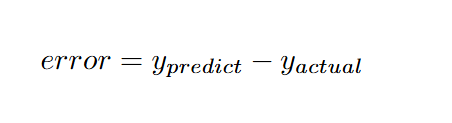

- Cost Function


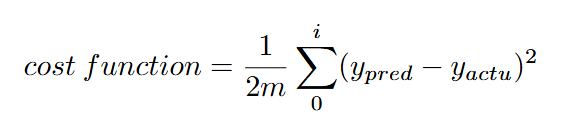

In [26]:
#prepare init
import numpy as np
# add 1 every data point
X_train_feature = np.c_[np.ones(X_train_scaled.shape[0]),X_train_scaled]
# make coef + bias with all init 0
theta = np.zeros(X_train_feature.shape[1])
final_theta = None
lr = 0.01
epsilon = 1e-6
prev_cost = float('inf')

cost_history = []

for i in range(10000):

  y_train_pred = X_train_feature @ theta

  error = y_train_pred - y_train

  const_function = np.sum((error)**2) / (2 * len(X_train_feature))

  cost_history.append(const_function)

  # gradient
  gradient = (X_train_feature.T @ error) / len(X_train_feature)

  if (abs(prev_cost - const_function) < epsilon) or (np.linalg.norm(gradient) < epsilon) :
    print(f"stop iteration at {i}")
    final_theta = theta
    print(f"best theta is {theta}")
    print(f"cost function {const_function}")
    break
  prev_cost = const_function
  # update theta
  theta = theta - lr * gradient


stop iteration at 788
best theta is [14.09487431  3.76371471  2.78266609  0.06572953]
cost function 1.352635672564731


#### Evaluation

After we get best theta value, we evaluate the model performances by predicting y in train and test dataset. We measure the model performances using MSE and R<sup>2</sup>

In [6]:
X_test_feature = np.c_[np.ones(X_test_scaled.shape[0]),X_test_scaled]

# fit model
y_train_final = X_train_feature @ final_theta
y_test_final = X_test_feature @ final_theta

#evaluate
from sklearn.metrics import mean_squared_error, r2_score
mse_train = mean_squared_error(y_train,y_train_final)
mse_test = mean_squared_error(y_test,y_test_final)

r2_train = r2_score(y_train,y_train_final)
r2_test = r2_score(y_test,y_test_final)

print(f"MSE train {mse_train}")
print(f"MSE test {mse_test}")
print(f"R2 train {r2_train}")
print(f"R2 test {r2_test}")




MSE train 3.705930628008295
MSE test 4.248714928029573
R2 train 0.8571138607929714
R2 test 0.8653919144416319


Based on the training and testing loss values, the model shows similar performance on both datasets, since the MSE values are close (2.71 vs 3.18). This suggests that the model generalizes reasonably well and does not show clear signs of overfitting.

Based R<sup>2</sup> score, the model shows high R<sup>2</sup> score 89.9 % on both dataset, it means that linear model perform well in this case.

### Residual Plot

Beside we using R<sup>2</sup> and MSE to evaluate model performance, we also check regression assumption using residual plot

Text(0, 0.5, 'residual')

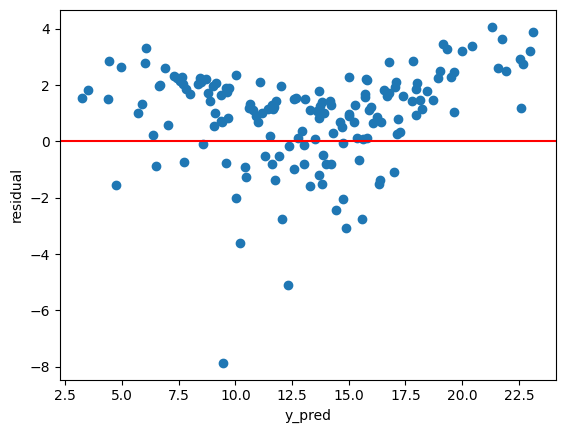

In [7]:
residual_train = y_train - y_train_final
from matplotlib import pyplot as plt
plt.scatter(y_train_final,residual_train)
plt.axhline(0,color='r')
plt.xlabel('y_pred')
plt.ylabel('residual')

Based on the residual plot, there is still a visible U-shaped pattern instead of random scatter around zero. This suggests that the linear model does not fully capture the underlying relationship between the features and the target. Therefore, the linearity assumption may not be fully satisfied, and a more complex model may be considered.

When U-Shape pattern show or other pattern in residual plot, if we forced to use linear model, the model will have **high bias/undefitting**

### Result
Based on MSE and R<sup>2</sup> score, we conclude that linear model is perform well in this case, However based on residual plot, there're U-shape pattern in residual plot that show there's still hidden pattern that model fail to capture and showing in residual plot, So the model performances is mild underfitting

## Underfitting

Underfitting happen when residual plot show U-shape pattern. In this section, we want to check the possible cause of underfitting

### Cost function history

Text(0, 0.5, 'cost')

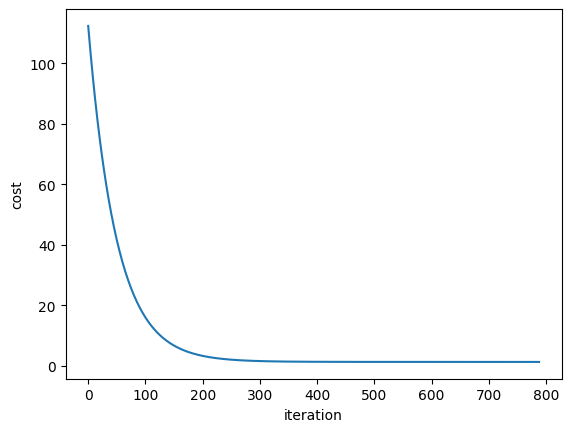

In [27]:
from matplotlib import pyplot as plt
plt.plot(cost_history)
plt.xlabel('iteration')
plt.ylabel('cost')

Based on the result, it show that the cost history vs iteration plot is converge. Converge happen when there'is small change cost function across iteration. So the number iteration, learning rate, and the epsilon that we used is good enough and not a factor that causing underfitting in this case.

below this is example when epsilon is not good used for gradient descent (1e-2) and seems causing underfittng

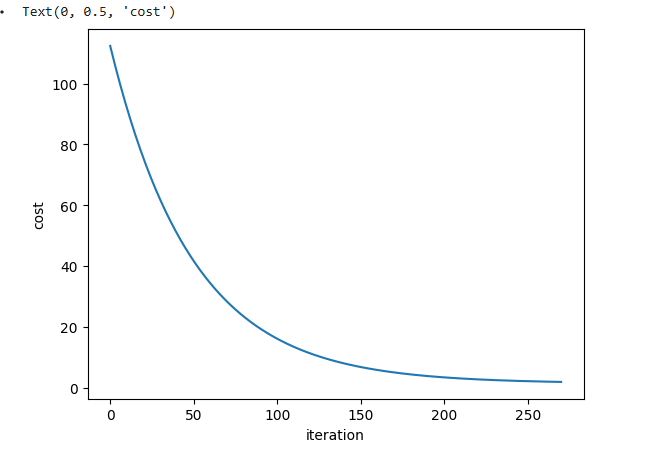

**Therefore, Hyperparameter (lr, iteration,epsilon) are not a factor causing underfitting in this case**

### Model Complexity

When residual plot show U-shape pattern, means that the model is too simple for capturing relationship between x and y variables, therefore we need more complex model. We can use Polynomial linear regression. Polynomial feature is a regression method that add polynomial features (x<sup>2</sup>) to capture non-linear relationship while keeping linear parameter. In this case, we want to use various degree from 2 until 5 for polynomial featrues

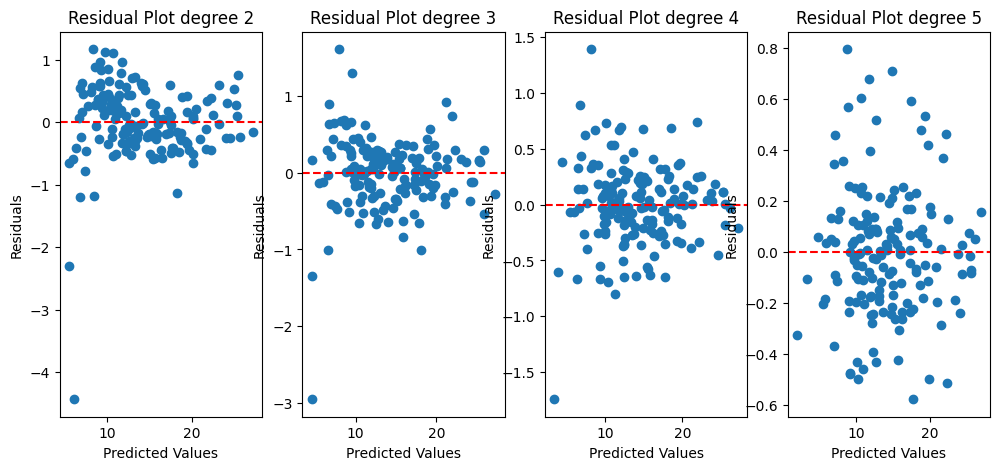

In [20]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
fig,ax = plt.subplots(1,len(range(2,6)),figsize=(12,5))
ax = ax.ravel()
degree = [2,3,4,5]
for i,j in enumerate(degree):

  # add x^2
  poly = PolynomialFeatures(degree=j,include_bias=False)
  X_poly_train = poly.fit_transform(X_train_scaled)
  X_poly_test = poly.transform(X_test_scaled)

  #linear regression
  model = LinearRegression()
  model.fit(X_poly_train,y_train)
  y_pred_train_poly = model.predict(X_poly_train)
  y_pred_test_poly = model.predict(X_poly_test)

  #evaluate
  residual_poly_train  =  y_train - y_pred_train_poly
  ax[i].scatter(y_pred_train_poly,residual_poly_train)
  ax[i].set_xlabel('Predicted Values')
  ax[i].set_ylabel('Residuals')
  ax[i].axhline(y=0, color='r', linestyle='--')
  ax[i].set_title(f"Residual Plot degree {j}")


Based on the result show that residual plot using degree = 4 seems become the best fit because spread randomly and scattered around zero,

After we see residual plot, we can also see performance of model based MSE and R2

In [24]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
ax = ax.ravel()
degree = [2,3,4,5]
for i,j in enumerate(degree):

  # add x^2
  poly = PolynomialFeatures(degree=j,include_bias=False)
  X_poly_train = poly.fit_transform(X_train_scaled)
  X_poly_test = poly.transform(X_test_scaled)

  #linear regression
  model = LinearRegression()
  model.fit(X_poly_train,y_train)
  y_pred_train_poly = model.predict(X_poly_train)
  y_pred_test_poly = model.predict(X_poly_test)

  # evaluate
  mse_train = mean_squared_error(y_train, y_pred_train_poly)
  mse_test = mean_squared_error(y_test, y_pred_test_poly)

  r2_train = r2_score(y_train, y_pred_train_poly)
  r2_test = r2_score(y_test, y_pred_test_poly)

  print(f"\nDegree {j}")
  print(f"MSE Train: {mse_train:.2f}")
  print(f"MSE Test: {mse_test:.2f}")
  print(f"R2 Train: {r2_train:.2f}")
  print(f"R2 Test:{r2_test:.2f}")


Degree 2
MSE Train: 0.36
MSE Test: 0.41
R2 Train: 0.99
R2 Test:0.99

Degree 3
MSE Train: 0.22
MSE Test: 0.29
R2 Train: 0.99
R2 Test:0.99

Degree 4
MSE Train: 0.14
MSE Test: 0.62
R2 Train: 0.99
R2 Test:0.98

Degree 5
MSE Train: 0.06
MSE Test: 76.50
R2 Train: 1.00
R2 Test:-1.42


Based on the result, degree 3 seems the best fit model because there're small gap between MSE train and MSE test. In degree 4, although based on residual plot seem the best fit model for this case, it has more larger gap than degree 3. **So we choose degree 3 for the best fit model because has generalization performance better than degree 4**

## Final Result

In [30]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
poly_degree_3 = PolynomialFeatures(degree=3,include_bias=False)
#convert
X_poly_train_final = poly_degree_3.fit_transform(X_train_scaled)
X_poly_test_final = poly_degree_3.transform(X_test_scaled)

model_lr = LinearRegression()
model_lr.fit(X_poly_train_final,y_train)
y_pred_train_final = model_lr.predict(X_poly_train_final)

# coefisien and intercept
print(f"intercept ; {model.intercept_}")
print(f"coeficient: {model.coef_}")
print(f"\ndegree: {poly_degree_3.get_feature_names_out()}")


intercept ; 14.410813364534194
coeficient: [ 3.56288589  2.23957474  0.07388741  0.01846659  1.32784685 -0.09381834
  0.07890439 -0.19523668 -0.03239828 -0.55683932  0.51956388 -0.62591933
 -0.08809121  0.79488483 -0.4225162   0.54216171 -0.20319838  0.41183609
  0.14772481 -0.24381591 -0.07102522  0.02061653 -0.01132538 -0.01638892
 -0.08121683  0.0720581   0.0688402  -0.1239245   0.03912989  0.01371598
 -0.04424194  0.07881758  0.07788172  0.11474657  0.22884899 -0.14957268
  0.22086778  0.16142183 -0.35883523  0.2448855  -0.1121304   0.06880574
 -0.0884725   0.10254758 -0.0661375  -0.08228754  0.03705956 -0.11298987
  0.04140054 -0.09939841  0.09966917 -0.21096916  0.01084371 -0.05406323
 -0.07487635]

degree: ['x0' 'x1' 'x2' 'x0^2' 'x0 x1' 'x0 x2' 'x1^2' 'x1 x2' 'x2^2' 'x0^3'
 'x0^2 x1' 'x0^2 x2' 'x0 x1^2' 'x0 x1 x2' 'x0 x2^2' 'x1^3' 'x1^2 x2'
 'x1 x2^2' 'x2^3']


In [35]:
from IPython.display import display,Math


# coef and intercept
coef = model_lr.coef_
intercept = model.intercept_
features = poly_degree_3.get_feature_names_out()

# equation
equ = f"f(x) = {intercept:.2f}"

for i,j in zip(coef,features):
  feature_j =  j.replace(" ","")
  equ += f" + ({i:.2f}{feature_j})"

# display
print("model polynomial for predictiong sales : \n")
display(Math(equ))

model polynomial for predictiong sales : 



<IPython.core.display.Math object>

## Conclusion

To predict sales based on advertising budgets for TV, radio, and newspaper, a simple linear regression model was initially applied. However, the residual plot showed a U-shaped pattern, indicating underfitting and suggesting that the linear model was too simple to capture the underlying relationship between the input variables and sales. After checking the possible causes of underfitting, we found that the issue was not caused by the optimization hyperparameters, since the model had already converged. Therefore, we increased the model complexity by applying polynomial regression. Based on the training and testing performance, degree 3 polynomial regression provided the best balance between model fit and generalization performance, making it the most suitable model for predicting sales.